# NLP — Лабораторная работа №1
## Сентимент-анализ отзывов Кинопоиска: сырой текст → regex → лемматизация

**Вариант 8**

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# ВАШ ВАРИАНТ (номер по списку группы)
VARIANT = 8

# Логика назначения параметров (не меняйте этот код)
if 1 <= VARIANT <= 5:
    MODEL_CLASS = LogisticRegression
    NGRAMS = (1, 1)
elif 6 <= VARIANT <= 10:
    MODEL_CLASS = LogisticRegression
    NGRAMS = (1, 2)
elif 11 <= VARIANT <= 15:
    MODEL_CLASS = LinearSVC
    NGRAMS = (1, 1)
else:
    raise ValueError("Вариант должен быть от 1 до 15!")

# Уникальное зерно случайности для вашего среза данных
RANDOM_STATE = VARIANT

print(f"Ваш вариант: {VARIANT}")
print(f"Модель для пайплайна: {MODEL_CLASS.__name__}, N-граммы: {NGRAMS}")

Ваш вариант: 8
Модель для пайплайна: LogisticRegression, N-граммы: (1, 2)


сначала пробую сам пройтись разобраться, потом посмотрим, что клод предлагает 

загрузим стоп-слова

In [2]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/anryzhov/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/anryzhov/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Шаг 1. Загрузка данных и подготовка выборок

In [3]:
import os
import pandas as pd
from datasets import load_dataset


CACHE = "kinopoisk_cache.parquet"

def load_kinopoisk() -> pd.DataFrame:
    """Загружает blinoff/kinopoisk (train). 
    
    Если прямой способ не сработал - пробует запасные.
    :return: датасет, скоторым мы будем работать дальше
    :rtype: pd.DataFrame
    """
    if os.path.exists(CACHE):
        return pd.read_parquet(CACHE)

    attempts = [
        {},                                    # обычная загрузка
        {"revision": "refs/convert/parquet"},  # parquet-версия, если скрипт датасета не поддерживается
        {"trust_remote_code": True},           # для старых версий datasets
    ]
    last_error = None
    for kwargs in attempts:
        try:
            ds = load_dataset("blinoff/kinopoisk", split="train", **kwargs)
            data = pd.DataFrame(ds)
            try:
                data.to_parquet(CACHE)
            except Exception:
                pass
            return data
        except Exception as e:
            last_error = e
            print(f"Не получилось с параметрами {kwargs}: {type(e).__name__}")
    raise RuntimeError(f"Не удалось загрузить датасет: {last_error}")


raw_df = load_kinopoisk()


print("Колонки датасета:\n", list(raw_df.columns))

ds = load_dataset("blinoff/kinopoisk", split="train")
df = pd.DataFrame(ds)

print("Колонки датасета:", list(raw_df.columns))
df.head(3)

/home/anryzhov/study/nlp/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Колонки датасета:
 ['part', 'movie_name', 'review_id', 'author', 'date', 'title', 'grade3', 'grade10', 'content']


Колонки датасета: ['part', 'movie_name', 'review_id', 'author', 'date', 'title', 'grade3', 'grade10', 'content']


,part,movie_name,review_id,author,date,title,grade3,grade10,content
0,top250,Блеф (1976),17144,Come Back,2011-09-24,Плакали наши денежки ©,Good,10,"\n""Блеф» — одна из моих самых любимых комедий...."
1,top250,Блеф (1976),17139,Stasiki,2008-03-04,NaN,Good,0,\nАдриано Челентано продолжает радовать нас св...
2,top250,Блеф (1976),17137,Flashman,2007-03-04,NaN,Good,10,"\nНесомненно, это один из великих фильмов 80-х..."


## Подготавливаем колонки с таргетом

#### выделяем названия колонкок

In [4]:
# Названия колонок в датасете могут отличаться от методички (там написано content/grade).
TEXT_COL = "content"
GRADE_COL = "grade10"
print(f"текст: '{TEXT_COL}' \nоценка: '{GRADE_COL}'")

# Оставляем только нужные колонки: текст и оценку
df = raw_df[[TEXT_COL, GRADE_COL]].copy()
df.columns = ["content", "grade"]

текст: 'content' 
оценка: 'grade10'


#### превращаем оценки в бинарный формат

In [5]:
df.head()

,content,grade
0,"\n""Блеф» — одна из моих самых любимых комедий....",10
1,\nАдриано Челентано продолжает радовать нас св...,0
2,"\nНесомненно, это один из великих фильмов 80-х...",10
3,\nЭта фраза на мой взгляд отражает сюжет несом...,0
4,"\n- как пела Земфира, скорее всего, по соверше...",7


#### Удаляем пустые отзывы и строки без оценки

In [6]:
before_dropna = len(df)
df.dropna(subset=["content", "grade"], inplace=True)
df = df[df["content"].str.strip() != ""]
print("До/после очистки:", before_dropna - len(df))

До/после очистки: 0


In [7]:
df["grade"] = pd.to_numeric(df["grade"], errors="coerce")

#### Бинаризируем оценки

In [8]:
print("Значения оценок в данных:", sorted(int(g) for g in df["grade"].unique()))
df.info()

df["label"] = df["grade"].apply(lambda x: 1 if x > 5 else 0)

print("Баланс классов (доли):")
print(df["label"].value_counts(normalize=True).round(3))

Значения оценок в данных: [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 10, 11, 12, 14, 15, 20, 100, 110, 1000, 100500, 10000000]
<class 'pandas.DataFrame'>
RangeIndex: 36591 entries, 0 to 36590
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   content  36591 non-null  str    
 1   grade    36591 non-null  float64
dtypes: float64(1), str(1)
memory usage: 126.9 MB
Баланс классов (доли):
label
1    0.551
0    0.449
Name: proportion, dtype: float64


#### Уникальный срез: 10_000 случайных отзывов (зерно = номер варианта)

In [9]:
from sklearn.model_selection import train_test_split


df_sample = df.sample(n=min(10_000, len(df)), random_state=RANDOM_STATE)


X_train, X_test, y_train, y_test = train_test_split(
    df_sample["content"], 
    df_sample["label"],
    test_size=0.2,  # 20% уходит на тест
    random_state=RANDOM_STATE,
    stratify=df_sample["label"],  # балансируем
)

print(f"размер обучающей выборки: {len(X_train)}")
print(f"размер тестовой выборки: {len(X_test)}")

размер обучающей выборки: 8000
размер тестовой выборки: 2000


## Шаг 2. Универсальная функция для пайплайна

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from nltk.corpus import stopwords
import nltk



nltk.download("stopwords", quiet=True)
stop_words = stopwords.words("russian")


def create_pipeline(preprocessor=None) -> Pipeline:
    """Создает sklearn Pipeline для классификации текста.

    :param preprocessor: функция для очистки текста (по умолчанию None - сырой текст)
    :type preprocessor: 
    :return: объект Pipeline
    :rtype: Pipeline
    """
    pipe = Pipeline([
        # Векторизация текста
        ("vectorizer", TfidfVectorizer(
            preprocessor=preprocessor,
            ngram_range=NGRAMS,  # (ун/биграммы)
            stop_words=stop_words,
        )),
        # Классификация
        ("classifier", MODEL_CLASS(random_state=RANDOM_STATE)),
    ])
    
    return pipe

test_pipe = create_pipeline()
print(test_pipe)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(ngram_range=(1, 2),
                                 stop_words=['и', 'в', 'во', 'не', 'что', 'он',
                                             'на', 'я', 'с', 'со', 'как', 'а',
                                             'то', 'все', 'она', 'так', 'его',
                                             'но', 'да', 'ты', 'к', 'у', 'же',
                                             'вы', 'за', 'бы', 'по', 'только',
                                             'ее', 'мне', ...])),
                ('classifier', LogisticRegression(random_state=8))])


## Шаг 3. Эксперимент 1 — бейзлайн на «сырых» текстах

In [11]:
pipe_raw = create_pipeline(preprocessor=None)
pipe_raw.fit(X_train, y_train)
y_pred_raw = pipe_raw.predict(X_test)

# используем f1 потому что классы могут быть несбалансированы
f1_raw = f1_score(y_test, y_pred_raw)
print(f"F1-score на сырых текстах: {f1_raw:.4f}")

F1-score на сырых текстах: 0.8066


Как и указано в методичке - резльтат между [0.75-0.85]. Следующим делом проверим, улучшится ли результат после очистки данных.

## Шаг 4. Эксперимент 2 — очистка текста (regex)

In [12]:
import re


def clean_text(text: str) -> str:
    """Функция, которая очищает текст

    Использует регулярные выражения, чтобы вырезать ненужные части текста
    :param text: исходный (сырой) текст
    :type text: str
    :return: очищенный текст
    :rtype: str
    """
    # Защита от пустых значений (если вдруг попадется NaN)
    if not isinstance(text, str):
        return ""
    
    # 1. Нижний регистр
    text = text.lower()

    # 2. Удаляем HTML-теги
    text = re.sub(r"<[^>]+>", " ", text)

    # 3. Удаляем ссылки
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 4. Удаляем знаки препинания и цифры 
    # (оставляем кириллицу, латиницу и пробелы)
    text = re.sub(r"[^a-zа-яё\s]", " ", text)

    # 5. Убираем лишние пробелы
    text = re.sub(r"\s+", " ", text).strip()

    return text

#### Тест на одной строке

In [13]:
sample_text = "Посмотрел <b>фильм</b> вчера в 23:00... Это просто УЖАС!!! Ссылка: http://example.com"
print("До:   ", sample_text)
print("После:", clean_text(sample_text))

До:    Посмотрел <b>фильм</b> вчера в 23:00... Это просто УЖАС!!! Ссылка: http://example.com
После: посмотрел фильм вчера в это просто ужас ссылка


Ожидаемый вывод: После: посмотрел фильм вчера в это просто ужас ссылка (test passed)

In [14]:
pipe_clean = create_pipeline(preprocessor=clean_text)
pipe_clean.fit(X_train, y_train)
y_pred_clean = pipe_clean.predict(X_test)

f1_clean = f1_score(y_test, y_pred_clean)
print(f"F1-score на очищенных текстах: {f1_clean:.4f}")
print(f"Разница с сырыми текстами: {f1_clean - f1_raw:+.4f}")

F1-score на очищенных текстах: 0.7521
Разница с сырыми текстами: -0.0545


скор упал. Лично я думаю, что виноват препроцессор, потому что он удаляет все цифры безжалостно, тем самым потенциально лишая модель полезной информации. Пример: "фильм - 10/10, 5 звезд! "

## Шаг 5. Эксперимент 3 — лемматизация (pymorphy3 + lru_cache)

In [15]:
!pip install pymorphy3


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [16]:
import pymorphy3
from functools import lru_cache


# Анализатор тяжелый - создаем один раз
morph = pymorphy3.MorphAnalyzer()


@lru_cache(maxsize=100_000)  # кэшируем до 100 000 уникальных слов
def get_lemma(word: str) -> str:
    """Берем первую (самую вероятную) лемму"""
    return morph.parse(word)[0].normal_form


def lemmatize_text(text: str) -> str:

    # 1. Сначала очищаем текст
    text = clean_text(text)
    # 2. Разбиваем на слова
    words = text.split()
    # 3. Лемматизируем каждое слово (через кэш)
    lemmatized_words = [get_lemma(word) for word in words]
    # 4. Склеиваем обратно в строку
    return " ".join(lemmatized_words)

Тестовый запуск

In [17]:
sample = "Коты сидели на подоконниках и смотрели на птиц."
print("До:   ", clean_text(sample))
print("После:", lemmatize_text(sample))

До:    коты сидели на подоконниках и смотрели на птиц
После: кот сидеть на подоконник и смотреть на птица


Ожидаемый вывод после: кот сидеть на подоконник и смотреть на птица (test passed)

In [18]:
# Этот шаг самый долгий (от 30 секунд до пары минут)
pipe_lemma = create_pipeline(preprocessor=lemmatize_text)
pipe_lemma.fit(X_train, y_train)
y_pred_lemma = pipe_lemma.predict(X_test)

f1_lemma = f1_score(y_test, y_pred_lemma)
print(f"F1-score на лемматизированных текстах: {f1_lemma:.4f}")
print(f"Разница с очищенными текстами: {f1_lemma - f1_clean:+.4f}")

/home/anryzhov/study/nlp/venv/lib/python3.14/site-packages/sklearn/feature_extraction/text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['большой', 'весь', 'всё', 'ещё', 'мочь', 'нибыть', 'свой', 'хороший', 'это'] not in stop_words.
  warnings.warn(


F1-score на лемматизированных текстах: 0.7461
Разница с очищенными текстами: -0.0061


результат сильно не поменялся. Это как раз описано в методичке. Зачастую люди пишут коротко и используют одни и те же формы слов. То есть даже без лемматизации модель справляется неплохо. Скорее всего, если бы мы использовали весь датасет, где намного больше данных - результат был бы более значимым

## Шаг 6. Оценка и анализ лучшей модели

In [19]:
# Выбираем лучший этап по F1 автоматически
stages = {
    "1. Сырой текст":            (f1_raw,   y_pred_raw,   pipe_raw),
    "2. Очистка (Regex)":        (f1_clean, y_pred_clean, pipe_clean),
    "3. Лемматизация (pymorphy3)": (f1_lemma, y_pred_lemma, pipe_lemma),
}
best_stage = max(stages, key=lambda k: stages[k][0])
best_f1, best_y_pred, best_pipe = stages[best_stage]

print(f"Лучший этап: {best_stage}")
print(f"Лучшая метрика F1: {best_f1:.4f}")

Лучший этап: 1. Сырой текст
Лучшая метрика F1: 0.8066


Самым лучшим этапом оказался пайплайн с сырыми данными. Это нетипичная ситуация, обычно лучше всех лемматизированный текст.

#### Подробный отчет классификации

In [20]:
from sklearn.metrics import classification_report


print(classification_report(
    y_test, 
    best_y_pred, 
    target_names=["Негатив (0)", "Позитив (1)"])
    )

              precision    recall  f1-score   support

 Негатив (0)       0.90      0.49      0.64       899
 Позитив (1)       0.70      0.95      0.81      1101

    accuracy                           0.75      2000
   macro avg       0.80      0.72      0.72      2000
weighted avg       0.79      0.75      0.73      2000



вывод: рекол на негативе меньше 0.6, а это значит, что модель частенько ошибается, принимая негативные отзывы за позитивные, то есть FP. 

С метрикой Precision все в порядке, она хороша.
Как мне кажется, другие метрики тоже впорядке

In [21]:
!pip install matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


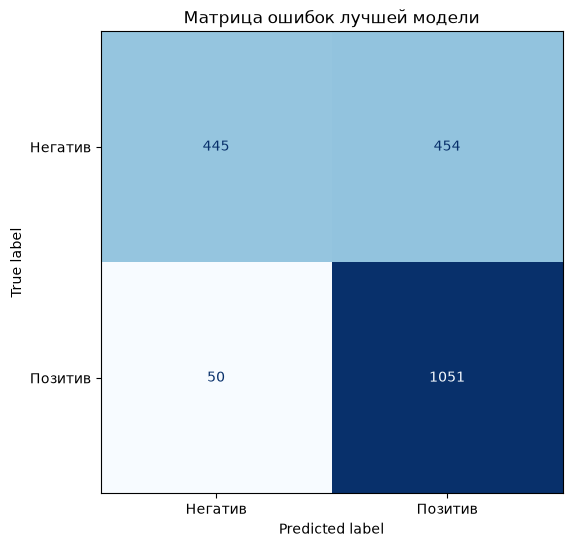

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_y_pred,
    display_labels=["Негатив", "Позитив"],
    ax=ax,
    cmap="Blues",
    colorbar=False,
)
plt.title("Матрица ошибок лучшей модели")
plt.show()

модель частенько принимает негатив за позитив. Вполне вероятно, что люди пишут сухие отзывы, хотя оценку ставят хорошую (10). Это могут быть бабушки, которые не слишком дружат с клавиатурой и пишут фактами "сойдет. качественный актер. стихи хороши. 'но хотелось повеситься' ".

In [23]:
import numpy as np

vectorizer = best_pipe.named_steps["vectorizer"]
classifier = best_pipe.named_steps["classifier"]

feature_names = vectorizer.get_feature_names_out()
coefs = classifier.coef_[0]

top_neg_indices = np.argsort(coefs)[:10]
top_pos_indices = np.argsort(coefs)[-10:][::-1]

print("Топ-10 слов, влияющих на НЕГАТИВ (класс 0):")
for idx in top_neg_indices:
    print(f"  {feature_names[idx]}: {coefs[idx]:.3f}")

print("\nТоп-10 слов, влияющих на ПОЗИТИВ (класс 1):")
for idx in top_pos_indices:
    print(f"  {feature_names[idx]}: {coefs[idx]:+.3f}")

Топ-10 слов, влияющих на НЕГАТИВ (класс 0):
  вообще: -2.066
  кино: -1.022
  баллов: -0.978
  снимать: -0.962
  бред: -0.955
  видимо: -0.920
  почему: -0.893
  хуже: -0.877
  создатели: -0.822
  снять: -0.809

Топ-10 слов, влияющих на ПОЗИТИВ (класс 1):
  10: +18.440
  10 10: +11.740
  очень: +1.980
  роли: +1.450
  всё: +1.397
  своей: +1.353
  мультфильм: +1.319
  истории: +1.303
  который: +1.259
  взгляд: +1.210


неудивительно, что всякие десятки попали в топ позитивных маркеров позитивного отзыва. Однако это чревато тем, что пользователь может писать что то вроде "фильм мог бы претендовать на 10/10, однако концовка испортила все впечатление. Ставллю 1 балл".



Интересное наблюдение: из биграмм здесь только 10 10

## Шаг 7. Сводная таблица и выводы

In [24]:
from IPython.display import display

results = pd.DataFrame({
    "Этап обработки": list(stages.keys()),
    "F1-score": [f1_raw, f1_clean, f1_lemma],
    "Размер словаря": [
        len(p.named_steps["vectorizer"].vocabulary_) for p in (pipe_raw, pipe_clean, pipe_lemma)
    ],
})

# Разница относительно сырого текста (в процентных пунктах)
results["Дельта к baseline (%)"] = (results["F1-score"] - f1_raw) * 100

results["F1-score"] = results["F1-score"].round(4)
results["Дельта к baseline (%)"] = results["Дельта к baseline (%)"].round(2)

print("Сводные результаты эксперимента:")
display(results)

Сводные результаты эксперимента:


,Этап обработки,F1-score,Размер словаря,Дельта к baseline (%)
0,1. Сырой текст,0.8066,1233708,0.00
1,2. Очистка (Regex),0.7521,1227151,-5.45
2,3. Лемматизация (pymorphy3),0.7461,884978,-6.05


### Выводы по лабораторной работе

Ячейка ниже собирает текст выводов из **ваших фактических чисел** (метрики, матрица ошибок, топ-слова).
Прочитайте результат, убедитесь, что он совпадает с вашими графиками, и при желании переформулируйте своими словами.

1. **Сравнение этапов предобработки.** В ходе эксперимента лучший F1-score 0.8066 достигнут на этапе «1. Сырой текст». Значения: 
```
сырой текст - 0.8066, 
regex-очистка - 0.7521, 
лемматизация - 0.7461.
```

Очистка текста регулярными выражениями: F1 снизился (-5.45). Это произошло потому, что словарь сократился с 1233708 до 1227151, но вместе с шумом удалились цифры и символы, которые несли часть эмоциональной окраски (например, оценки вида «10/10», «!!!» и не только).

Лемматизация: F1 снизился относительно очистки (-0.061; относительно сырого текста - -6.05). Это связано снова с сокращением словаря, но pymorphy3 берёт самый вероятный разбор слова без учёта контекста и иногда ошибается (омонимы), а различия форм (например, «хорошо» / «хороший») иногда несут тональность.
2. **Анализ ошибок модели.** По матрице ошибок модель чаще ошибается на классе 0 (негатив): негативные отзывы принимаются за позитивные (454 ошибок против 50 в обратную сторону). Это ошибка типа False Positive. Возможная причина: в негативных отзывах нередко много сарказма и похвалы фильму/актёрам при низкой итоговой оценке, а позитивный класс преобладает в данных и модель смещается к нему. Доля позитивных отзывов в тесте - 0.55. Самые «негативные» признаки: вообще, кино, баллов, снимать, бред; самые «позитивные»: 10, 10 10, очень, роли, всё.

3. **Влияние варианта (вариант № 8)**. В моём варианте использовалась модель LogisticRegression с N-граммами (1, 2) (униграммы + биграммы). В топе весов есть только одна пара слов: «10 10». Биграммы позволяют модели учитывать устойчивые сочетания, а не только отдельные слова, однако практика показала, что самыми показательными весами оказались униграммы. Важное ограничение: частица «не» входит в список русских стоп-слов NLTK и удаляется до построения биграмм. Поэтому пары вида «не понравился» в словаре не возникают, а биграммы склеивают только соседние оставшиеся слова. Отрицание модель по-прежнему не различает; для этого пришлось бы убрать «не» из стоп-слов. Логистическая регрессия - линейная и прозрачная: веса слов можно прочитать напрямую, как в списках выше, и она выдаёт вероятности классов.